### Config

In [218]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import zscore

from v2_data_preparation import load_and_prepare_data, slice_by_dates

In [219]:
# Config
wells_fp = '../outputs/collahuasi_wells/consolidated_collahuasi_wells.csv'
model = 'noAnchored'     # two-years, first-year, second-year, noAnchored

if model == 'two-years':
    predictions_fp1 = '../outputs/predictions/SDH1_2000-2026_two-years.csv'
    predictions_fp2 = '../outputs/predictions/SDH2_2000-2026_two-years.csv'
elif model == 'first-year':
    predictions_fp1 = '../outputs/predictions/SDH1_2000-2026_first-year.csv'
    predictions_fp2 = '../outputs/predictions/SDH2_2000-2026_first-year.csv'
elif model == 'second-year':
    predictions_fp1 = '../outputs/predictions/SDH1_2000-2026_second-year.csv'
    predictions_fp2 = '../outputs/predictions/SDH2_2000-2026_second-year.csv'
elif model == 'noAnchored':
    predictions_fp1 = '../outputs/predictions/SDH1_2000-2026_noAnchored_difRolling.csv'
    predictions_fp2 = '../outputs/predictions/SDH2_2000-2026_noAnchored_difRolling.csv'
else:
    print(f'{model} not supported as model choice')

# sdh1ps01_elev = 3782.5  # CS6 
# sdh2pp01_elev = 3786.9  # CS8

sdh1ps01_elev = 3786.0  # HPS-11
sdh2pp01_elev = 3783.1  # HPS-06

sigma_threshold = 3

### Data preparation

In [220]:
# Read wells csv
wells = pd.read_csv(
    wells_fp,
    parse_dates=['date']
    )

# Pivot wells csv to wide format
wells_masl_pivoted = wells.pivot_table(
    index='date',
    columns='name',
    values='level_masl',
    aggfunc='mean'
).reset_index().set_index('date').round(2)

# Resample to monthly frequency (nans are dropped)
wells_masl_monthly = wells_masl_pivoted.resample('MS').mean(
# ).dropna(axis=0, how='all'
         )

# Clip to dates
wells_masl_monthly = slice_by_dates(wells_masl_monthly, '2005', '2015')

In [221]:
# Read predictions csv
pred1 = load_and_prepare_data(
    filepath=predictions_fp1,
    index_col='Timestamps'
)

# Transform mbgs to masl (and invert values)
pred1['predicted_masl'] = (sdh1ps01_elev - (pred1['predicted'] * -1)).round(2)

# Resample to monthly frequency
#pred1_masl_monthly = pred1.resample('MS').mean()

# Clip to Collahuasi sample range
pred1_masl_daily = slice_by_dates(pred1, wells_masl_monthly.index.min(), wells_masl_monthly.index.max())
pred1_masl_monthly = slice_by_dates(pred1, wells_masl_monthly.index.min(), wells_masl_monthly.index.max())

In [222]:
# Read predictions csv
pred2 = load_and_prepare_data(
    filepath=predictions_fp2,
    index_col='Timestamps'
)

# Transform mbgs to masl (and invert values)
pred2['predicted_masl'] = (sdh2pp01_elev - (pred2['predicted'] * -1)).round(2)

# Resample to monthly frequency
#pred2_masl_monthly = pred2.resample('MS').mean()

# Clip to Collahuasi sample range
pred2_masl_daily = slice_by_dates(pred2, wells_masl_monthly.index.min(), wells_masl_monthly.index.max())
pred2_masl_monthly = slice_by_dates(pred2, wells_masl_monthly.index.min(), wells_masl_monthly.index.max())

In [223]:
# Estandarizacion de valores
wells_masl_monthly_z = wells_masl_monthly.apply(zscore, nan_policy='omit')

pred1_masl_daily_z = pred1_masl_daily.apply(zscore, nan_policy='omit')
pred1_masl_monthly_z = pred1_masl_monthly.apply(zscore, nan_policy='omit')

pred2_masl_daily_z = pred2_masl_daily.apply(zscore, nan_policy='omit')
pred2_masl_monthly_z = pred2_masl_monthly.apply(zscore, nan_policy='omit')

In [224]:
# Filtrado de outliers (sigma > 3)
sigma_threshold = sigma_threshold
is_outlier = np.abs(wells_masl_monthly_z) > sigma_threshold

clean_wells_masl_monthly = wells_masl_monthly.mask(is_outlier)
clean_wells_masl_monthly_z = wells_masl_monthly_z.mask(is_outlier)

### Vars

In [225]:
WELLS = wells_masl_monthly
WELLS_CLEAN = clean_wells_masl_monthly
WELLS_Z = wells_masl_monthly_z
WELLS_Z_CLEAN = clean_wells_masl_monthly_z

PRED1_MONTH = pred1_masl_monthly
PRED1_DAY = pred1_masl_daily
PRED1_MONTH_Z = pred1_masl_monthly_z
PRED1_DAY_Z = pred1_masl_daily_z 

PRED2_MONTH = pred2_masl_monthly
PRED2_DAY = pred2_masl_daily
PRED2_MONTH_Z = pred2_masl_monthly_z
PRED2_DAY_Z = pred2_masl_daily_z

### Correlations

In [226]:
def prepare_and_correlate(df1, df2, df1_vars = None, df2_vars = None, corr_method='pearson', min_obs = 30):
    """
    Filters data by selected variables, merges on datetime index, and calculates correlation.
    """
    # filter columns based on user selection
    if df1_vars:
        df1 = df1[df1_vars]
    if df2_vars:
        df2 = df2[df2_vars]

    # merge both datasets using their datetime index
    merged_data = pd.merge(
        df1, 
        df2, 
        left_index=True, 
        right_index=True, 
        how='inner'
    )

    # filter columns without minimum number of observations
    merged_data = merged_data.dropna(axis=1, thresh=min_obs)

    # calculate the correlation matrix
    correlation_matrix = merged_data.corr(
        method=corr_method,
        #min_periods=min_obs
    )
    
    return correlation_matrix, merged_data

In [227]:
corr_matrix1, merged1 = prepare_and_correlate(PRED1_MONTH, WELLS_CLEAN, 'predicted_masl', corr_method='spearman', min_obs=20)
corr_matrix2, merged2 = prepare_and_correlate(PRED2_MONTH, WELLS_CLEAN, 'predicted_masl', corr_method='spearman', min_obs=20)

In [228]:
corr_matrix1['predicted_masl'].sort_values(ascending=False)

predicted_masl    1.000000
HPS-11            0.635502
HPS-06            0.341646
HPS-12            0.261771
HPS-01            0.124268
HPS-07            0.090484
HPS-04            0.051870
HPS-14            0.000910
HPS-36           -0.001296
HPS-37           -0.015409
HPS-05           -0.221587
HPS-38           -0.254034
HPS-08           -0.429949
HPS-02                 NaN
HPS-03                 NaN
Name: predicted_masl, dtype: float64

In [229]:
corr_matrix2['predicted_masl'].sort_values(ascending=False)

predicted_masl    1.000000
HPS-11            0.538789
HPS-06            0.275459
HPS-01            0.193952
HPS-12            0.186039
HPS-36            0.056104
HPS-07            0.036062
HPS-14           -0.041866
HPS-37           -0.050867
HPS-04           -0.073314
HPS-05           -0.255722
HPS-38           -0.383923
HPS-08           -0.529264
HPS-02                 NaN
HPS-03                 NaN
Name: predicted_masl, dtype: float64

### Time series plotting

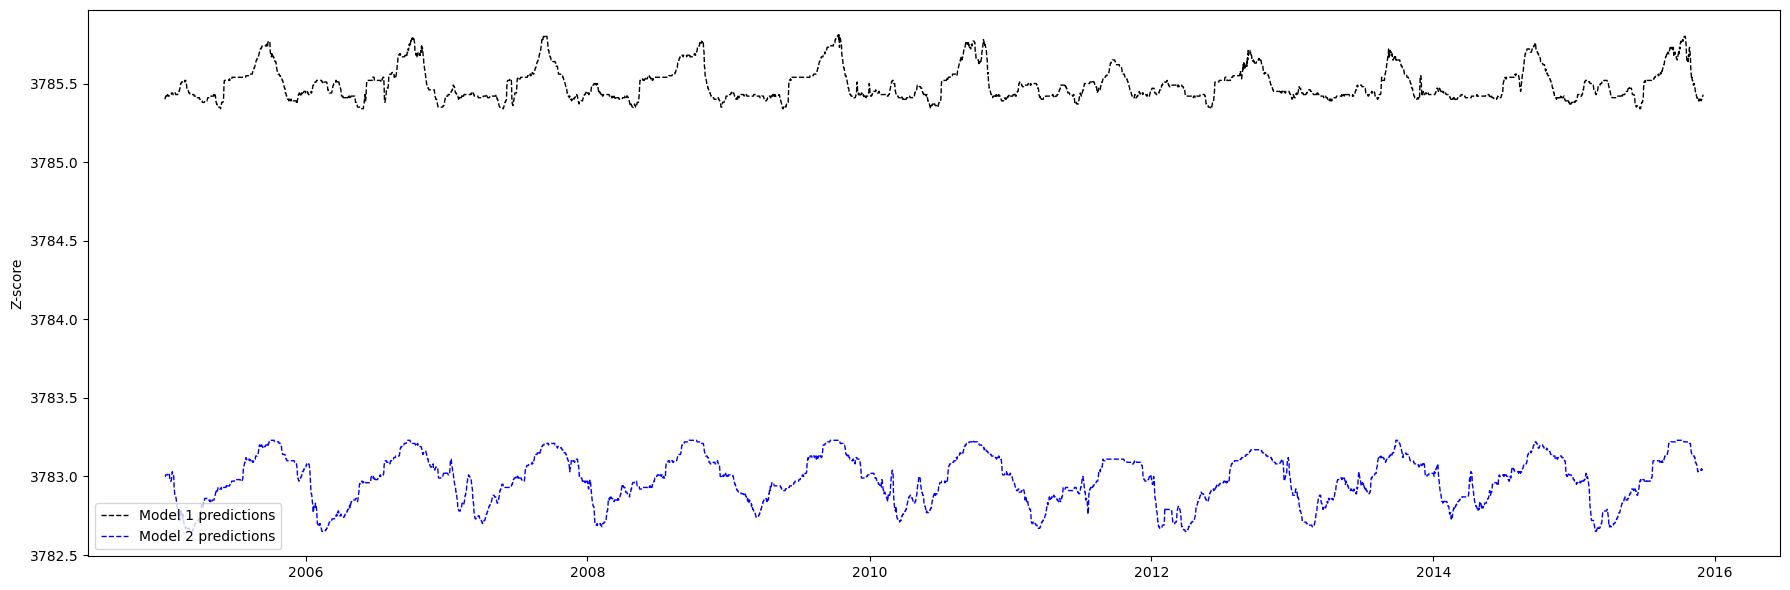

In [230]:
pred1_var = pred1_masl_daily
pred2_var = pred2_masl_daily
wells_var = clean_wells_masl_monthly

fig, ax1 = plt.subplots(figsize=(18,6))

ax1.plot(pred1_var.index, pred1_var['predicted_masl'], 
         label='Model 1 predictions', color='black', linewidth=1, linestyle='--')
ax1.plot(pred2_var.index, pred2_var['predicted_masl'], 
         label='Model 2 predictions', color='blue', linewidth=1, linestyle='--')

# ax1.plot(wells_var.index, wells_var['HPS-06'], label='HPS-06', marker='x')
# ax1.plot(wells_var.index, wells_var['HPS-11'], label='HPS-11', marker='x')


ax1.set_ylabel('Z-score')
ax1.legend(loc='lower left')

plt.tight_layout()
plt.show()

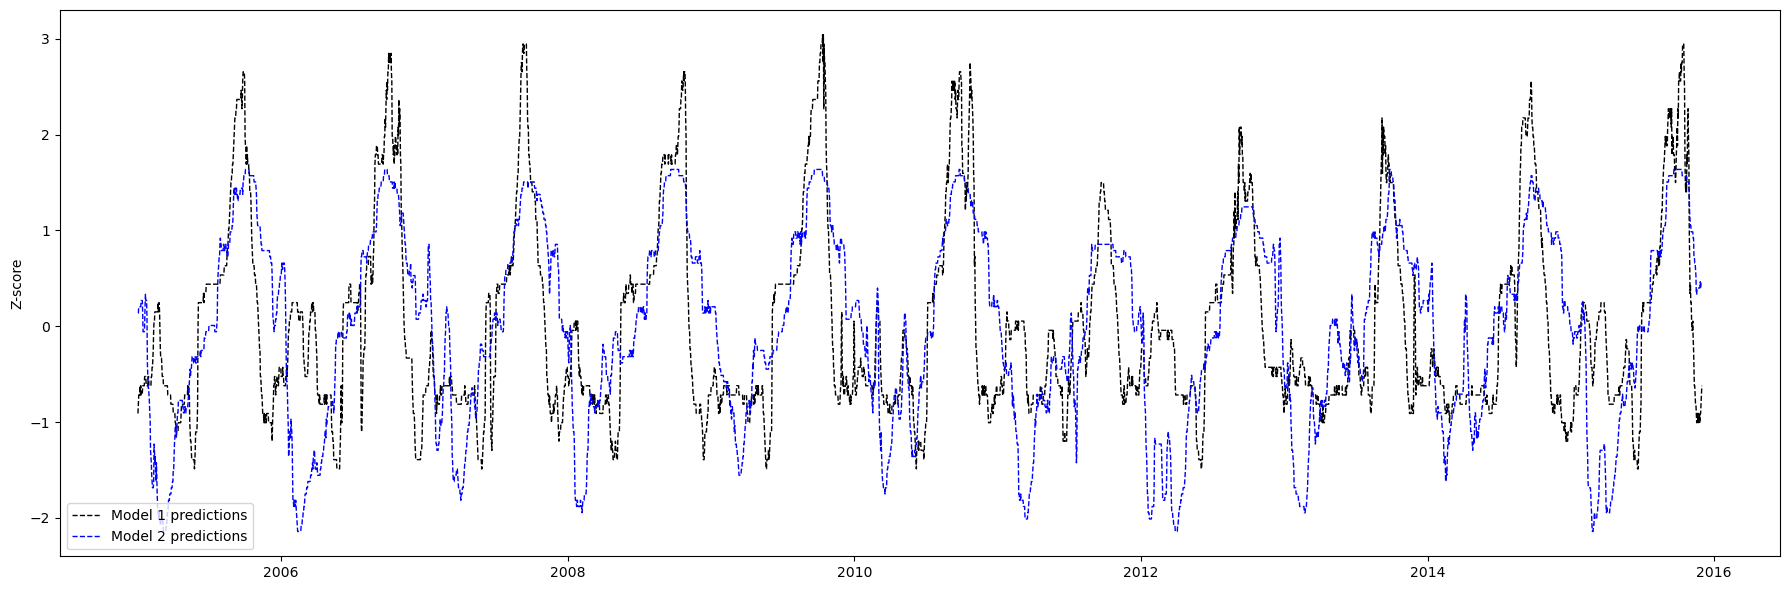

In [231]:
pred1_var = pred1_masl_daily_z
pred2_var = pred2_masl_daily_z
wells_var = clean_wells_masl_monthly_z

fig, ax1 = plt.subplots(figsize=(18,6))

ax1.plot(pred1_var.index, pred1_var['predicted_masl'], 
         label='Model 1 predictions', color='black', linewidth=1, linestyle='--')
ax1.plot(pred2_var.index, pred2_var['predicted_masl'], 
         label='Model 2 predictions', color='blue', linewidth=1, linestyle='--')

# ax1.plot(wells_var.index, wells_var['HPS-06'], label='HPS-06', marker='x')
# ax1.plot(wells_var.index, wells_var['HPS-11'], label='HPS-11', marker='x')


ax1.set_ylabel('Z-score')
ax1.legend(loc='lower left')

plt.tight_layout()
plt.show()

#### SDH1

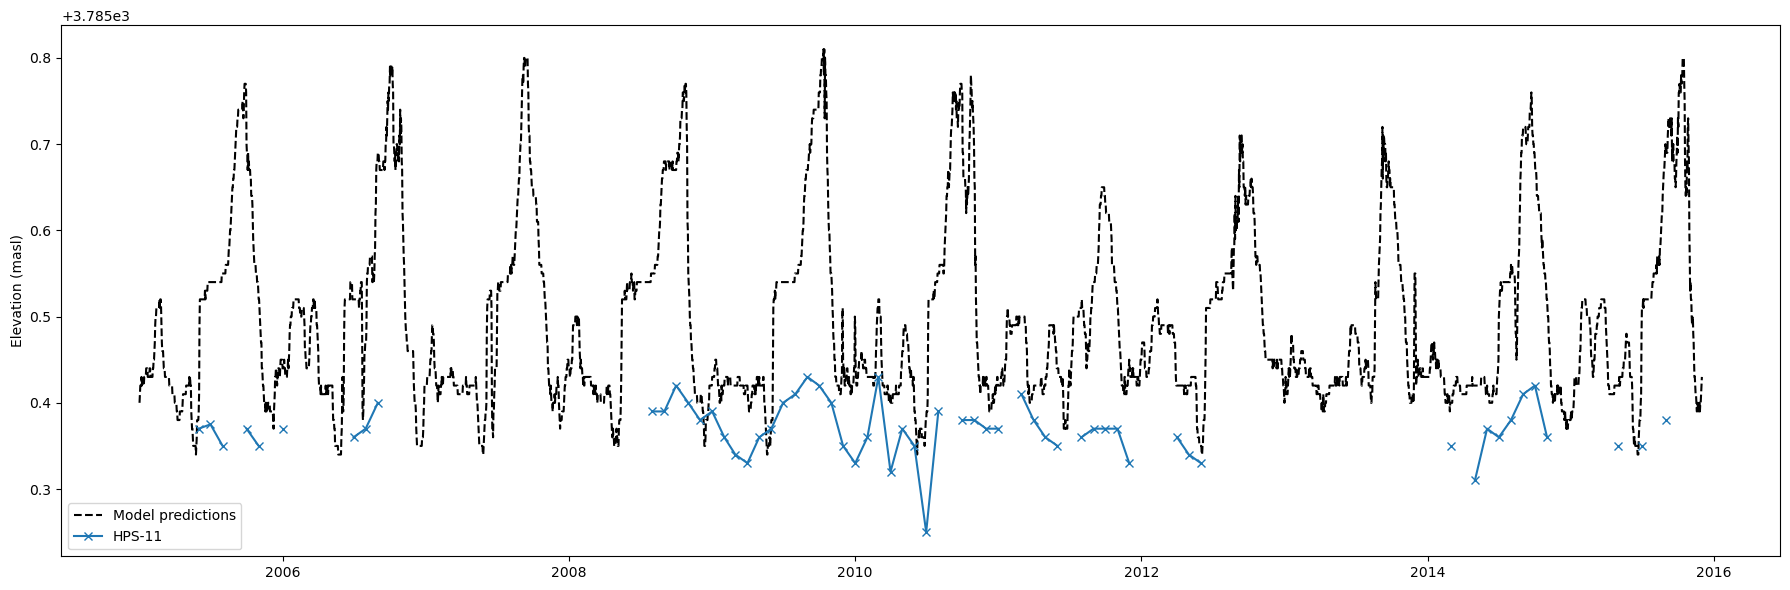

In [232]:
pred_var = pred1_masl_monthly
wells_var = clean_wells_masl_monthly

fig, ax1 = plt.subplots(figsize=(18,6))

ax1.plot(pred_var.index, pred_var['predicted_masl'], 
         label='Model predictions', color='black', linewidth=1.5, linestyle='--')

# Bofedal Huasco Norte
# ax1.scatter(wells_var.index, wells_var['HPS-01'], label='HPS-01')
# ax1.scatter(wells_var.index, wells_var['P2'], label='P2')
# ax1.scatter(wells_var.index, wells_var['CS1'], label='CS1')

# # Rio Collacagua
ax1.plot(wells_var.index, wells_var['HPS-11'], label='HPS-11', marker='x')
# ax1.scatter(wells_var.index, wells_var['HPS-12'], label='HPS-12')   # 5m prof

# # Pampa entre ZN y rio Collacagua
# ax1.scatter(wells_var.index, wells_var['HPS-13'], label='HPS-13')
# ax1.scatter(wells_var.index, wells_var['HPS-14'], label='HPS-14')   # 4m prof
# ax1.scatter(wells_var.index, wells_var['CS6'], label='CS6')
# ax1.scatter(wells_var.index, wells_var['C9'], label='C9')

# # Nucleo salino
# ax1.scatter(wells_var.index, wells_var['CS10'], label='CS10')
# ax1.scatter(wells_var.index, wells_var['C10'], label='C10')
# ax1.scatter(wells_var.index, wells_var['C11'], label='C11')
# ax1.scatter(wells_var.index, wells_var['C12'], label='C12')


ax1.set_ylabel('Elevation (masl)')
ax1.legend(loc='lower left')

plt.tight_layout()
plt.show()

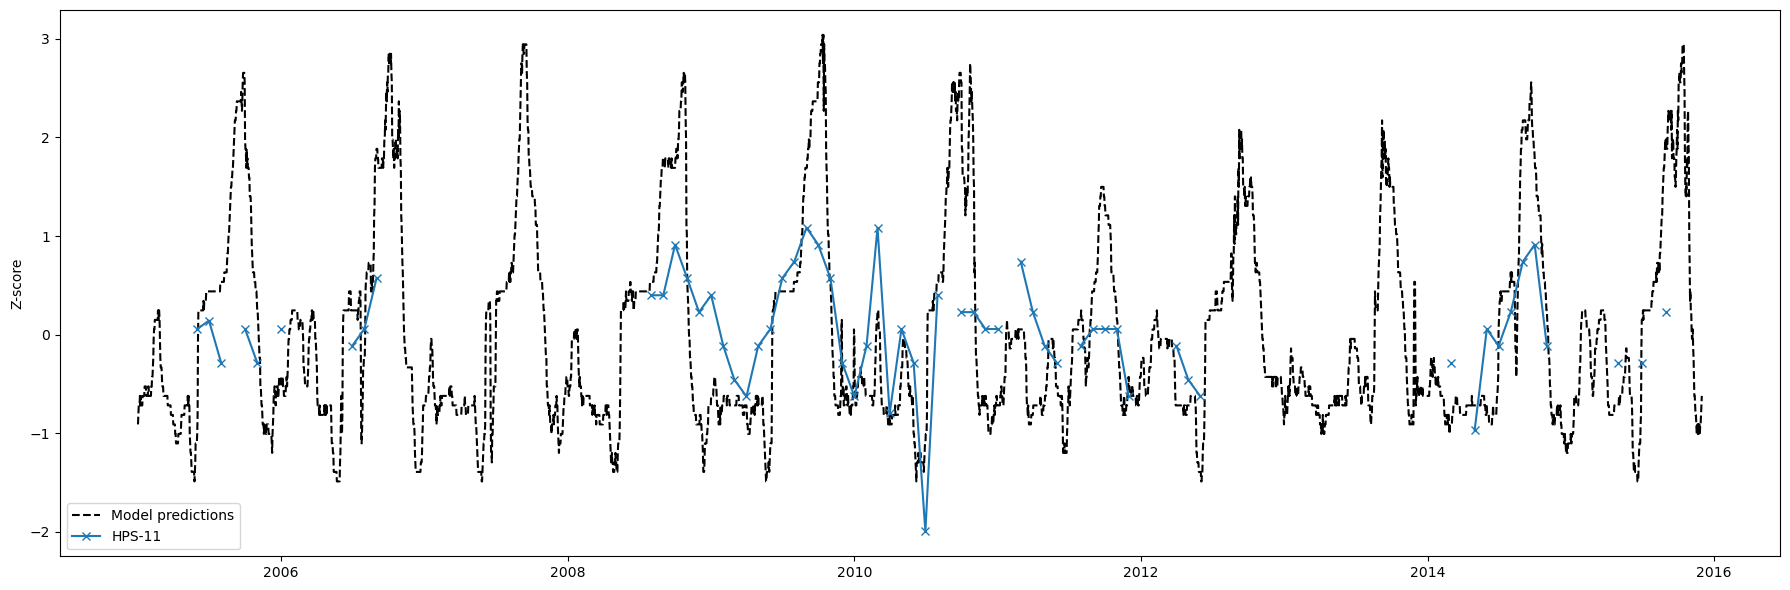

In [233]:
pred_var = pred1_masl_monthly_z
wells_var = clean_wells_masl_monthly_z

fig, ax1 = plt.subplots(figsize=(18,6))

ax1.plot(pred_var.index, pred_var['predicted_masl'], 
         label='Model predictions', color='black', linewidth=1.5, linestyle='--')

# Bofedal Huasco Norte
# ax1.plot(wells_var.index, wells_var['HPS-01'], label='HPS-01', marker='x')
# ax1.scatter(wells_var.index, wells_var['P2'], label='P2')
# ax1.scatter(wells_var.index, wells_var['CS1'], label='CS1')

# # Rio Collacagua
ax1.plot(wells_var.index, wells_var['HPS-11'], label='HPS-11', marker='x')
# ax1.plot(wells_var.index, wells_var['HPS-12'], label='HPS-12', marker='x')   # 5m prof

# # Pampa entre ZN y rio Collacagua
# ax1.plot(wells_var.index, wells_var['HPS-13'], label='HPS-13', marker='x')
# ax1.scatter(wells_var.index, wells_var['HPS-14'], label='HPS-14')   # 4m prof

# ax1.scatter(wells_var.index, wells_var['C9'], label='C9')
#ax1.scatter(wells_var.index, wells_var['CS6'], label='CS6')


# # Nucleo salino
#ax1.scatter(wells_var.index, wells_var['CS7'], label='CS7')
# ax1.scatter(wells_var.index, wells_var['CS10'], label='CS10')
# ax1.scatter(wells_var.index, wells_var['C10'], label='C10')
# ax1.scatter(wells_var.index, wells_var['C11'], label='C11')
# ax1.scatter(wells_var.index, wells_var['C12'], label='C12')


ax1.set_ylabel('Z-score')
ax1.legend(loc='lower left')

plt.tight_layout()
plt.show()

#### SDH2

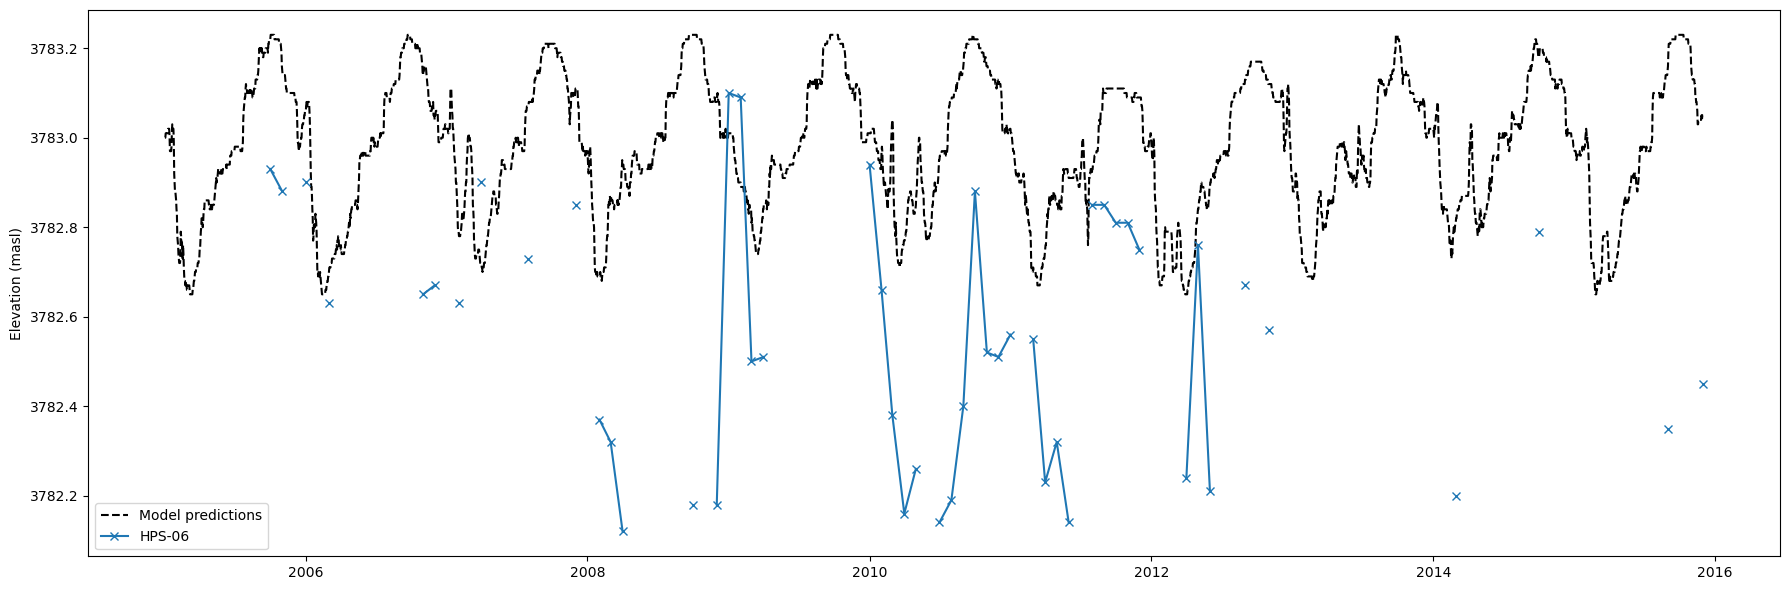

In [234]:
pred_var = pred2_masl_monthly
wells_var = clean_wells_masl_monthly

fig, ax1 = plt.subplots(figsize=(18,6))

ax1.plot(pred_var.index, pred_var['predicted_masl'], 
         label='Model predictions', color='black', linewidth=1.5, linestyle='--')

#ax1.plot(wells_var.index, wells_var['HPS-01'], label='HPS-01', marker='x')

# Vertiente refugio sur
# ax1.plot(wells_var.index, wells_var['HPS-07'], label='HPS-07', marker='x')
# ax1.scatter(wells_var.index, wells_var['HPS-08'], label='HPS-08')   # 6m prof
# ax1.scatter(wells_var.index, wells_var['HPS-38'], label='HPS-38')   # 4m prof
# ax1.scatter(wells_var.index, wells_var['HPS-39'], label='HPS-39')   # 4m prof
# ax1.scatter(wells_var.index, wells_var['HPS-40'], label='HPS-40')   # 6m prof
# ax1.scatter(wells_var.index, wells_var['CS22'], label='CS22')
# ax1.scatter(wells_var.index, wells_var['CS23'], label='CS23')
# ax1.scatter(wells_var.index, wells_var['P11'], label='P11')

# Desembocadura rinconada
# ax1.scatter(wells_var.index, wells_var['HPS-09'], label='HPS-09')
# ax1.scatter(wells_var.index, wells_var['HPS-10'], label='HPS-10')
# # en sal
# ax1.scatter(wells_var.index, wells_var['CS8'], label='CS8')

# # Llaretales cono
# ax1.scatter(wells_var.index, wells_var['C14'], label='C14')

# # Final vertiente ZS
# ax1.scatter(wells_var.index, wells_var['CS17'], label='CS17')

# # Final qda pupusal
# ax1.scatter(wells_var.index, wells_var['CS18'], label='CS18')

# Sur salar
# ax1.plot(wells_var.index, wells_var['HPS-05'], label='HPS-05', marker='x')
ax1.plot(wells_var.index, wells_var['HPS-06'], label='HPS-06', marker='x')

# Rio Collacagua
#ax1.plot(wells_var.index, wells_var['HPS-11'], label='HPS-11', marker='x')

ax1.set_ylabel('Elevation (masl)')
ax1.legend(loc='lower left')

plt.tight_layout()
plt.show()

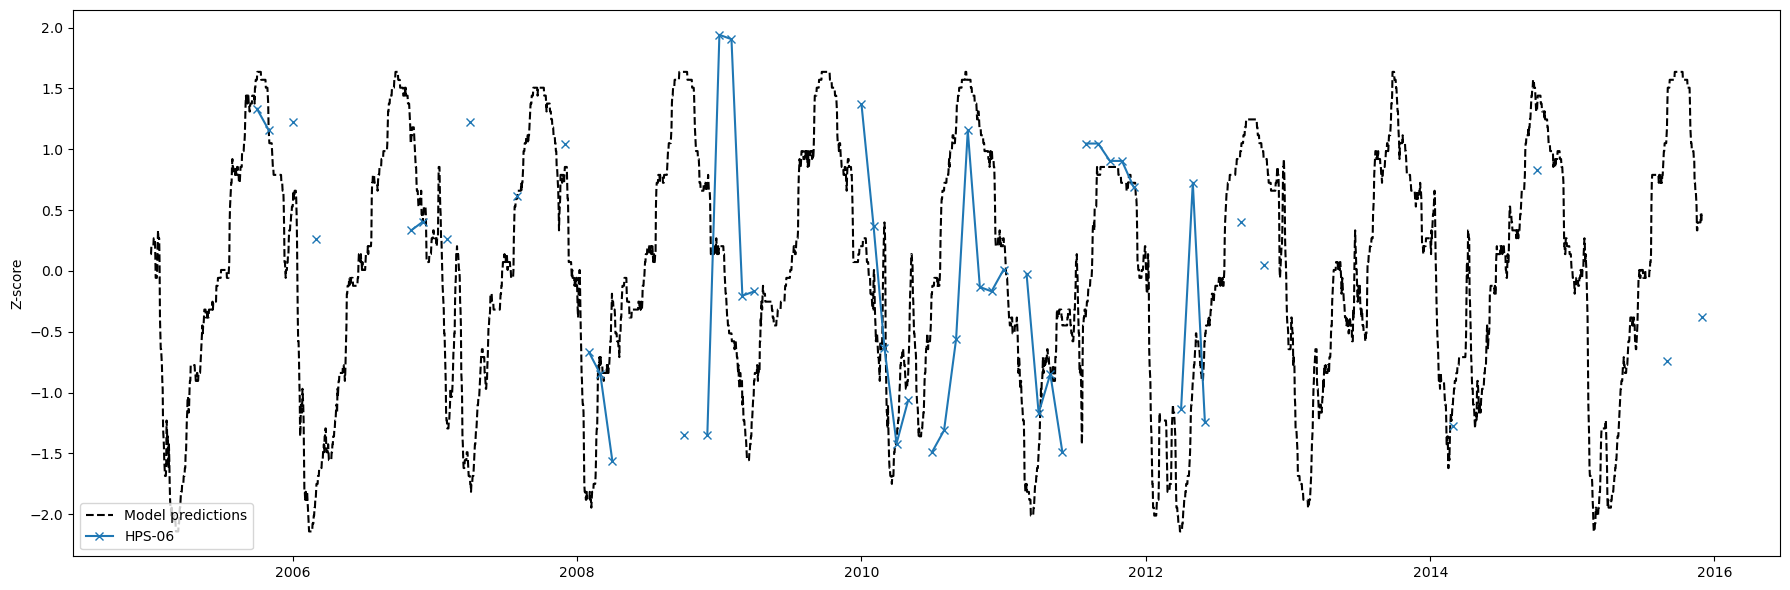

In [235]:
pred_var = pred2_masl_monthly_z
wells_var = clean_wells_masl_monthly_z

fig, ax1 = plt.subplots(figsize=(18,6))

ax1.plot(pred_var.index, pred_var['predicted_masl'], 
         label='Model predictions', color='black', linewidth=1.5, linestyle='--')

#ax1.plot(wells_var.index, wells_var['HPS-01'], label='HPS-01', marker='x')

# Vertiente refugio sur
#ax1.plot(wells_var.index, wells_var['HPS-07'], label='HPS-07', marker='x')
# ax1.scatter(wells_var.index, wells_var['HPS-08'], label='HPS-08')   # 6m prof
# ax1.scatter(wells_var.index, wells_var['HPS-38'], label='HPS-38')   # 4m prof
# ax1.scatter(wells_var.index, wells_var['HPS-39'], label='HPS-39')   # 4m prof
# ax1.scatter(wells_var.index, wells_var['HPS-40'], label='HPS-40')   # 6m prof
# ax1.scatter(wells_var.index, wells_var['CS22'], label='CS22')
# ax1.scatter(wells_var.index, wells_var['CS23'], label='CS23')
# ax1.scatter(wells_var.index, wells_var['P11'], label='P11')

# Desembocadura rinconada
# ax1.scatter(wells_var.index, wells_var['HPS-09'], label='HPS-09')
# ax1.scatter(wells_var.index, wells_var['HPS-10'], label='HPS-10')
# en sal
#ax1.scatter(wells_var.index, wells_var['CS8'], label='CS8')

# # Llaretales cono
# ax1.scatter(wells_var.index, wells_var['C14'], label='C14')

# # Final vertiente ZS
# ax1.scatter(wells_var.index, wells_var['CS17'], label='CS17')

# # Final qda pupusal
# ax1.scatter(wells_var.index, wells_var['CS18'], label='CS18')

# Sur salar
# ax1.plot(wells_var.index, wells_var['HPS-05'], label='HPS-05', marker='x')
ax1.plot(wells_var.index, wells_var['HPS-06'], label='HPS-06', marker='x')

# Rio Collacagua
# ax1.plot(wells_var.index, wells_var['HPS-11'], label='HPS-11', marker='x')

ax1.set_ylabel('Z-score')
ax1.legend(loc='lower left')

plt.tight_layout()
plt.show()

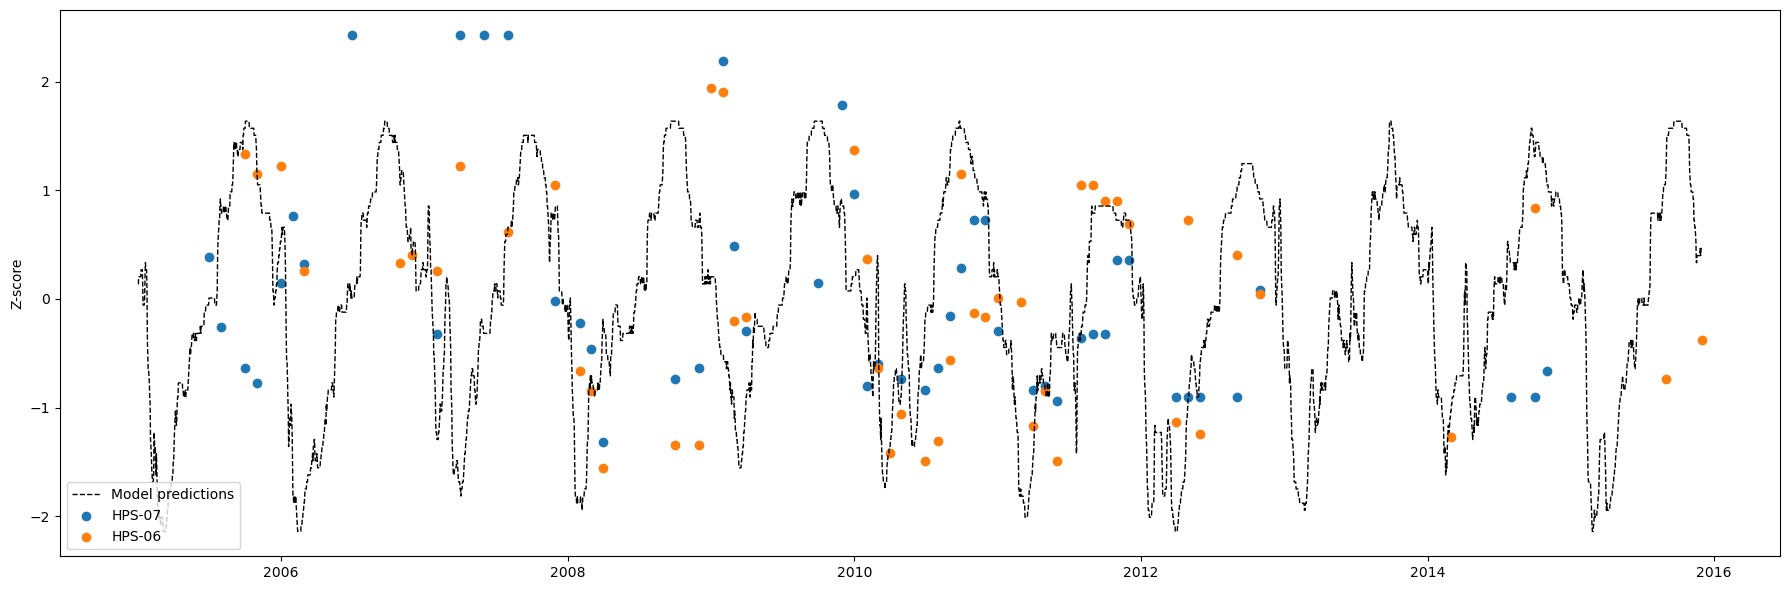

In [236]:
pred_var = pred2_masl_monthly_z
wells_var = clean_wells_masl_monthly_z

fig, ax1 = plt.subplots(figsize=(18,6))

ax1.plot(pred_var.index, pred_var['predicted_masl'], 
         label='Model predictions', color='black', linewidth=1, linestyle='--')

# Vertiente refugio sur
ax1.scatter(wells_var.index, wells_var['HPS-07'], label='HPS-07')

# Sur salar
ax1.scatter(wells_var.index, wells_var['HPS-06'], label='HPS-06')

# Rio Collacagua
#ax1.plot(wells_var.index, wells_var['HPS-11'], label='HPS-11', marker='x')

ax1.set_ylabel('Z-score')
ax1.legend(loc='lower left')

plt.tight_layout()
plt.show()